In [2]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

#from prettyprint 

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu

from train_mod_cog import RNNModel

device = eg_utils.get_device()

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# ! cp -r  $SCRATCH"/eg_paper/mod_cog/exp8_pruning_cooldown_0715" "/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/"

# Defining folders with experiments 

In [5]:
# results_dir =  Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0709") 
# results_dir = Path(os.path.join(os.environ['SCRATCH'], "eg_paper/mod_cog/exp8_pruning_cooldown_1123"))
results_dir = Path(os.path.join(os.environ['SCRATCH'], "eg_paper/mod_cog/exp8_cSGD_pruning_cooldown_1123"))
# results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715/")

os.listdir(results_dir)[:]
#results_dir =  Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_pruning_cooldown_0715") 

['cgd_N2500_lr0.05_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'cgd_N2500_lr0.075_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'cgd_N2500_lr0.1_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'cgd_N2500_lr0.25_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'cgd_N2500_lr0.5_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'cgd_N2500_lr0.75_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9',
 'cgd_N2500_lr0.01_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'cgd_N2500_lr0.05_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'cgd_N2500_lr0.075_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'cgd_N2500_lr0.1_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.925',
 'cgd_N2500_lr0.25_m0.9_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_c

In [6]:
! ls "/network/projects/_groups/linclab_users/eg/modcog/"

analysis	     cSGD			 exp8_pruning_cooldown_0715
analysis_dsa	     data			 neurogym
analysis_dsa_fixlen  data_v2			 pingsheng_rebuttal
analysis_dsa_v2      exp8_final_combined
analysis_fpf	     exp8_pruning_cooldown_0709


In [7]:
prune_props = [0.9,0.925, 0.95, 0.975, 0.99]
results_dict = {str(pp): {} for pp in prune_props}
for exp_folder in os.listdir(results_dir):
    pp = exp_folder.split("_ff")[-1]
    #print(pp)
    #print(exp_folder.split("_")[3])
    if exp_folder.split("_")[3] != "m0.925":
        continue
    exp_key = "_".join([exp_folder.split("_")[0], exp_folder.split("_")[2],exp_folder.split("_")[3]]) 
    results_dict[pp][exp_key] = au.DotDict({"exp_path": results_dir/exp_folder}) 

In [8]:
results_dict["0.9"]

{'cgd_lr0.01_m0.925': {'exp_path': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_cSGD_pruning_cooldown_1123/cgd_N2500_lr0.01_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'cgd_lr0.05_m0.925': {'exp_path': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_cSGD_pruning_cooldown_1123/cgd_N2500_lr0.05_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'cgd_lr0.075_m0.925': {'exp_path': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_cSGD_pruning_cooldown_1123/cgd_N2500_lr0.075_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'cgd_lr0.1_m0.925': {'exp_path': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_cSGD_pruning_cooldown_1123/cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss_ff0.9')},
 'cgd_lr0.25_m0.925': {'exp_path': PosixPath('/network/scratch/p/pingsheng.li/eg_paper/mod_cog/exp8_cSGD_pruning_coo

In [9]:
def load_results(results_dict, verbose=True):
    """
    very slightly modified version from au
    """
    # load the results 
    for exp_name in results_dict.keys():
        #print(exp_name, end="")
        found, not_found = 0, 0
        seed_dirs= sorted(os.listdir(results_dict[exp_name]["exp_path"]), key=lambda x: int(x.split("_")[-1]))
        
        for seed_dir in seed_dirs[:]:
            results_dict[exp_name][seed_dir] = au.DotDict({"path": results_dict[exp_name].exp_path/seed_dir})

            # grab checkpoint filepaths
            epoch_ckpts_dir = results_dict[exp_name][seed_dir].path/"epoch_ckpts"
            dec_acc_ckpts_dir = results_dict[exp_name][seed_dir].path/"dec_acc_ckpts"
            results_dict[exp_name][seed_dir].epoch_ckpts = list(epoch_ckpts_dir.glob("*.pt"))
            results_dict[exp_name][seed_dir].dec_acc_ckpts = list(dec_acc_ckpts_dir.glob("*.pt"))

            if len(results_dict[exp_name][seed_dir].dec_acc_ckpts) == 0:
                if verbose: print("No dec_acc_ckpts found")
            else:
                results_dict[exp_name][seed_dir].dec_acc_ckpts = au.sort_dec_acc_checkpoints(results_dict[exp_name][seed_dir].dec_acc_ckpts)
            
            if len(results_dict[exp_name][seed_dir].epoch_ckpts) == 0:
                if verbose: print("No epoch_ckpts found")
            else:
                results_dict[exp_name][seed_dir].epoch_ckpts = au.sort_epoch_checkpoints(results_dict[exp_name][seed_dir].epoch_ckpts)

            # load the train and eval results
            try:
                results_dict[exp_name][seed_dir].train_results = np.load(results_dict[exp_name][seed_dir].path/"train_results.npy", allow_pickle=True)[()]
                results_dict[exp_name][seed_dir].eval_results  = np.load(results_dict[exp_name][seed_dir].path/"eval_results.npy", allow_pickle=True)[()]
                found += 1
            except:
                not_found +=1

            # load the config into a dict
            with open(results_dict[exp_name][seed_dir].path/"config.yaml", 'r') as file:
                # print("Loading config", results_dict[exp_name][seed_dir].path/"config.yaml")
                try:
                    config = au.DotDict(yaml.safe_load(file))
                    results_dict[exp_name][seed_dir].cfg = recursive_dot_dict(config)
                except:
                    pass
                    #print("error loading config", file)

        if verbose: print(f" : loaded {found} results from {found+not_found}")
    return results_dict

results_dict["0.9"] = load_results(results_dict["0.9"], verbose=False)

In [10]:
results_dict["0.9"].keys()

dict_keys(['cgd_lr0.01_m0.925', 'cgd_lr0.05_m0.925', 'cgd_lr0.075_m0.925', 'cgd_lr0.1_m0.925', 'cgd_lr0.25_m0.925', 'cgd_lr0.5_m0.925', 'cgd_lr0.75_m0.925', 'gd_lr0.01_m0.925', 'eg_lr0.1_m0.925', 'eg_lr0.5_m0.925', 'eg_lr0.75_m0.925', 'eg_lr1.25_m0.925', 'eg_lr1.5_m0.925', 'eg_lr1_m0.925', 'eg_lr2.0_m0.925', 'eg_lr2.5_m0.925', 'gd_lr0.05_m0.925', 'gd_lr0.075_m0.925', 'gd_lr0.1_m0.925', 'gd_lr0.25_m0.925', 'gd_lr0.5_m0.925', 'gd_lr0.75_m0.925'])

In [11]:
for pp in results_dict.keys():
    results_dict[pp] = load_results(results_dict[pp], verbose=False)
    for exp_name in results_dict[pp].keys():
        results_dict[pp][exp_name] = au.concat_seed_results(results_dict[pp][exp_name])
        

In [12]:
results_dict["0.9"]['eg_lr2.5_m0.925'].train_results.keys()

dict_keys(['Loss', 'Loss_auc', 'Mse_fixation', 'Acc', 'Dec Acc', 'Dec_Acc_auc', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'cos_sim_init_params'])

In [13]:
results_dict["0.9"]['eg_lr2.5_m0.925'].train_results['Dec Acc'].sum(axis=0).mean()

np.float64(959.9242620050907)

In [14]:
results_dict["0.9"]['eg_lr2.5_m0.925'].eval_results.keys()

dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])

In [15]:
results_dict["0.9"]['eg_lr2.5_m0.925'].eval_results.val_Dec_Acc.mean(axis=1)[-1]

np.float64(0.9827107452154159)

In [16]:
# need to plot u curves
# get the performance 

In [17]:
# get best results for each eg or gd
from collections import namedtuple

Results = namedtuple("SweepResults", ["key", "perf_metric", "test_dec_acc", "test_acc", "test_Loss"])

#perf_key = 'Dec Acc'
perf_key = "Loss"
best_settings = {}
sweep_summary = {}
for pp in results_dict.keys():
    gd_perfs = []
    eg_perfs = []
    cgd_perfs = []
    for exp_name in results_dict[pp].keys():
        # assess by sum/auc of training dec acc (more the better)
        #print(results_dict[pp][exp_name].train_results[perf_key].shape)
        perf_metric = results_dict[pp][exp_name].train_results[perf_key].sum(axis=0).mean()
        #perf_metric = results_dict[pp][exp_name].train_results[perf_key][-1,:].mean()

        #print(np.isnan(results_dict[pp][exp_name].train_results[perf_key]).any())
        
        if np.isnan(results_dict[pp][exp_name].train_results[perf_key]).any():
            continue
            
        test_dec_acc = results_dict[pp][exp_name].eval_results.test_Dec_Acc.mean(axis=1)[-1]
        test_acc = results_dict[pp][exp_name].eval_results.test_Acc.mean(axis=1)[-1]
        test_loss = results_dict[pp][exp_name].eval_results.test_Loss.mean(axis=1)[-1]

        r = Results(exp_name,perf_metric,test_dec_acc, test_acc,test_loss )
        if exp_name.startswith("eg"): eg_perfs.append(r)
        elif exp_name.startswith("cgd"): cgd_perfs.append(r)
        else: gd_perfs.append(r)
    
    if perf_key == "Dec Acc":
        sort_reverse = True
    else:
        sort_reverse = False
    gd_perfs = sorted(gd_perfs, key=lambda x: x[1], reverse=sort_reverse)
    eg_perfs = sorted(eg_perfs, key=lambda x: x[1], reverse=sort_reverse)
    cgd_perfs = sorted(cgd_perfs, key=lambda x: x[1], reverse=sort_reverse)
    
    print(f"{pp} pruned",)
    print(gd_perfs[0])
    print(eg_perfs[0])  
    print(cgd_perfs[0])
    sweep_summary[pp] = {"eg":eg_perfs, "gd":gd_perfs, "cgd": cgd_perfs}
    best_settings[pp] = {"eg":eg_perfs[0],"gd":gd_perfs[0], "cgd": cgd_perfs[0]}

sweep_summary = au.recursive_dot_dict(sweep_summary)
best_settings = au.recursive_dot_dict(best_settings)

0.9 pruned
SweepResults(key='gd_lr0.1_m0.925', perf_metric=np.float64(784.9596699953079), test_dec_acc=np.float64(0.9793070874214171), test_acc=np.float64(0.9927104009389878), test_Loss=np.float64(0.6564018005132676))
SweepResults(key='eg_lr2.0_m0.925', perf_metric=np.float64(681.4093374371529), test_dec_acc=np.float64(0.9826193169355392), test_acc=np.float64(0.9942127242088319), test_Loss=np.float64(0.6223822110891343))
SweepResults(key='cgd_lr0.1_m0.925', perf_metric=np.float64(769.1494950771332), test_dec_acc=np.float64(0.9799706240892411), test_acc=np.float64(0.9931013947725296), test_Loss=np.float64(0.6556226923465729))
0.925 pruned
SweepResults(key='gd_lr0.25_m0.925', perf_metric=np.float64(844.7261702537537), test_dec_acc=np.float64(0.980120357990265), test_acc=np.float64(0.9932204364538194), test_Loss=np.float64(0.6510167988538742))
SweepResults(key='eg_lr1.5_m0.925', perf_metric=np.float64(710.0907239437104), test_dec_acc=np.float64(0.9817898197174072), test_acc=np.float64(0.9

In [18]:
sweep_summary["0.9"] = au.recursive_dot_dict(sweep_summary["0.9"])
# best_settings["0.9"] = au.recursive_dot_dict(best_settings["0.9"])

In [ ]:
import pickle

def plot_sweep_summary(ss_dict, k):
    """
    verify that the lrs have covered the range of optimal values
    ss_list is the list of results for eg or gd for a given prune prop
    """
    cdict = {"gd":"#5170d7", "eg":"#fd411e", "cgd": "#41a62a"}
    c = cdict[k]
    ss_list = ss_dict[k]
    print(ss_list[0])
    # SweepResults(key='gd_lr0.1_m0.925', perf_metric=785.96556173563, test_dec_acc=0.9792914519309998, test_acc=0.9927197438478469, test_Loss=0.6563732743263244)

    # get diff momentums
    m_list = []
    for ss in ss_list:
        m = ss.key.split("_")[-1]
        if m not in m_list:
            m_list.append(m)
    print(m_list)
    fig, axs = plt.subplots(1, 4, figsize=(8, 2.), dpi=300)

    #ValueError: could not convert string to float: '0.1_m0.925'

    ss_list = sorted(ss_list, key=lambda x: float(x[0].split("lr")[-1].split("_")[0]), reverse=False)
    linestyles = ["-", "--", "-.", ":"]
    for i, m in enumerate(m_list):
        lrs = [float(r[0].split("lr")[-1].split("_")[0]) for r in ss_list if m in r.key]
        
        test_dec_accs = [r.test_dec_acc for r in ss_list if m in r.key]
        test_accs = [r.test_acc for r in ss_list if m in r.key]
        test_Losses =  [r.test_Loss for r in ss_list if m in r.key]
        perf_metrics = [r.perf_metric for r in ss_list if m in r.key]
        
        print(test_dec_accs)
        print(perf_metrics)
        print(lrs)
        
        
        print(axs.shape)
        #axs = [axs[i] for i in range(axs.shape[0])]
        #print(type(axs))
        ms = 3
        axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
        axs[0].set_yscale("log")
        axs[0].set_ylabel("Loss auc")
        
        
        axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
        axs[1].set_ylabel("Response\nAccuracy")
        
        axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
        axs[2].set_ylabel("Accuracy")
        
        axs[3].plot(lrs, test_Losses, "o-", markersize=ms, c=c,linestyle=linestyles[i])
        axs[3].set_ylabel("Final Loss")
    
    fig.suptitle(f"Prune proportion ") # set here for spacing
    for ax in axs:
        ax.set_xlabel("Learning rate")
        #ax.set_xticks(lrs)
        sns.despine(ax=ax)
        
    plt.tight_layout()
    
    return fig

def plot_best_results(eg_key, gd_key, cgd_key, results_dict, gd_c="#5170d7", eg_c="#fd411e", cgd_c="#41a62a",
                      fig1_size=None, fig2_size=None, pp=None):
    """
    results is the subdictionary for a given prune prop
    """
    line_alpha=0.2
    
    print(eg_key, results_dict[eg_key].train_results['Dec Acc'].mean(axis=1)[-1])
    print(gd_key, results_dict[gd_key].train_results['Dec Acc'].mean(axis=1)[-1])
    print(cgd_key, results_dict[cgd_key].train_results['Dec Acc'].mean(axis=1)[-1])
    print(results_dict[eg_key].eval_results.keys())
    print(eg_key, results_dict[eg_key].eval_results['test_Dec_Acc'].mean(axis=1)[-1])
    print(gd_key, results_dict[gd_key].eval_results['test_Dec_Acc'].mean(axis=1)[-1])
    print(cgd_key, results_dict[cgd_key].eval_results['test_Dec_Acc'].mean(axis=1)[-1])
    
    if fig1_size is None:
        fig1_size = (1.5,1.25)
    fig1 = plt.figure(figsize=fig1_size, dpi = 300)
    
    plt.plot(results_dict[eg_key].train_results['Dec Acc'], c=eg_c, alpha=0.2)
    plt.plot(results_dict[gd_key].train_results['Dec Acc'], c=gd_c, alpha=0.2)
    plt.plot(results_dict[cgd_key].train_results['Dec Acc'], c=cgd_c, alpha=0.2)
    plt.plot(results_dict[eg_key].train_results['Dec Acc'].mean(axis=1), c=eg_c, alpha=1)
    plt.plot(results_dict[gd_key].train_results['Dec Acc'].mean(axis=1), c=gd_c, alpha=1)
    plt.plot(results_dict[cgd_key].train_results['Dec Acc'].mean(axis=1), c=cgd_c, alpha=1)
    plt.xlabel("Update #")
    plt.ylabel("Training \nResponse Acc.", rotation=90)
    plt.xlim(0, 1000)
    plt.ylim(0.,1)
    plt.yticks([0,0.5,1])
    sns.despine(offset=2)
    # save data for plotting later
    eg_data = results_dict[eg_key].train_results['Dec Acc'].mean(axis=1)
    gd_data = results_dict[gd_key].train_results['Dec Acc'].mean(axis=1)
    cgd_data = results_dict[cgd_key].train_results['Dec Acc'].mean(axis=1)
    # save nonmean data
    eg_data_nonmean = results_dict[eg_key].train_results['Dec Acc']
    gd_data_nonmean = results_dict[gd_key].train_results['Dec Acc']
    cgd_data_nonmean = results_dict[cgd_key].train_results['Dec Acc']
    with open(f"plot_data/Fig2b_cSGD_response_acc_data_{pp}.pkl", "wb") as f:
        pickle.dump({
            "eg": eg_data,
            "gd": gd_data,
            "cgd": cgd_data,
            "eg_nonmean": eg_data_nonmean,
            "gd_nonmean": gd_data_nonmean,
            "cgd_nonmean": cgd_data_nonmean
        }, f)
    
    
    if fig2_size is None:
        fig2_size = (1.5,1.25)
    fig2 = plt.figure(figsize=fig2_size, dpi = 300)
    
    plt.plot(results_dict[eg_key].train_results['cos_sim_init_params'], c=eg_c, alpha=0.2)
    plt.plot(results_dict[gd_key].train_results['cos_sim_init_params'], c=gd_c, alpha=0.2)
    plt.plot(results_dict[cgd_key].train_results['cos_sim_init_params'], c=cgd_c, alpha=0.2)
    plt.plot(results_dict[eg_key].train_results['cos_sim_init_params'].mean(axis=1), c=eg_c, alpha=1)
    plt.plot(results_dict[gd_key].train_results['cos_sim_init_params'].mean(axis=1), c=gd_c, alpha=1)
    plt.plot(results_dict[cgd_key].train_results['cos_sim_init_params'].mean(axis=1), c=cgd_c, alpha=1)
    sns.despine(offset=2)
    plt.xlabel("Update #")
    plt.ylabel("Cosine sim vs \n0-shot pruned", rotation=90)
    plt.xlim(0, 1000)
    plt.ylim(0.9,1)
    plt.yticks([0.9,1])

    # save data for plotting later
    eg_cos_sim_data = results_dict[eg_key].train_results['cos_sim_init_params'].mean(axis=1)
    gd_cos_sim_data = results_dict[gd_key].train_results['cos_sim_init_params'].mean(axis=1)
    cgd_cos_sim_data = results_dict[cgd_key].train_results['cos_sim_init_params'].mean(axis=1)
    # save nonmean data 
    eg_cos_sim_data_nonmean = results_dict[eg_key].train_results['cos_sim_init_params']
    gd_cos_sim_data_nonmean = results_dict[gd_key].train_results['cos_sim_init_params']
    cgd_cos_sim_data_nonmean = results_dict[cgd_key].train_results['cos_sim_init_params']
    with open(f"plot_data/Fig2b_cSGD_cos_sim_data_{pp}.pkl", "wb") as f:
        pickle.dump({
            "eg": eg_cos_sim_data,
            "gd": gd_cos_sim_data,
            "cgd": cgd_cos_sim_data,
            "eg_nonmean": eg_cos_sim_data_nonmean,
            "gd_nonmean": gd_cos_sim_data_nonmean,
            "cgd_nonmean": cgd_cos_sim_data_nonmean
        }, f)   
    
    return fig1, fig2 

eg_lr2.0_m0.925 0.969851291179657
gd_lr0.1_m0.925 0.9669638276100159
cgd_lr0.1_m0.925 0.9677829265594482
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr2.0_m0.925 0.9826193169355392
gd_lr0.1_m0.925 0.9793070874214171
cgd_lr0.1_m0.925 0.9799706240892411


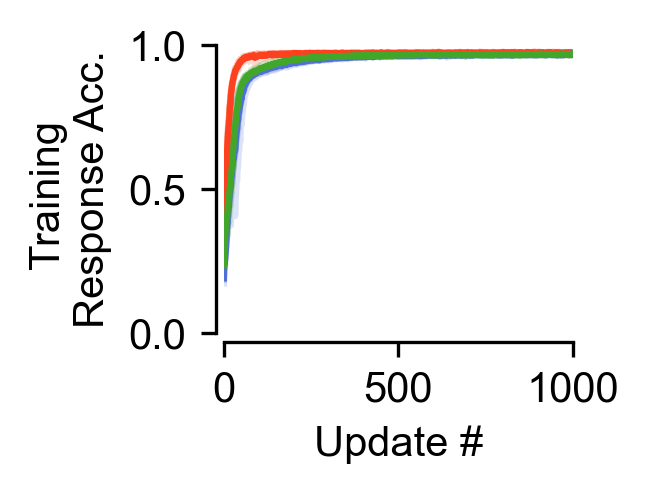

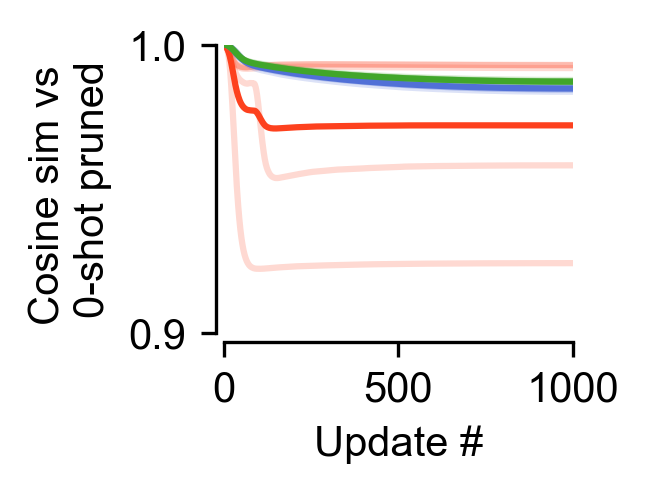

In [20]:
pp = "0.9"
fig1, fig2  = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], best_settings[pp].cgd[0], results_dict[pp] , pp=pp)

# fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300, transparent=True)
# fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)


In [21]:
# save the data for plotting 
# data_dict = {
#     "fig2b_cSGD_acc": {
#         "eg": results_dict[pp][best_settings[pp].eg[0]].train_results['Dec Acc'],
#         "gd": results_dict[pp][best_settings[pp].gd[0]].train_results['Dec Acc'],
#         "cgd": results_dict[pp][best_settings[pp].cgd[0]].train_results['Dec Acc'],
#     },
#     "fig2b_cSGD_cos_sim": {
#         "eg": results_dict[pp][best_settings[pp].eg[0]].train_results['cos_sim_init_params'],
#         "gd": results_dict[pp][best_settings[pp].gd[0]].train_results['cos_sim_init_params'],
#         "cgd": results_dict[pp][best_settings[pp].cgd[0]].train_results['cos_sim_init_params'],
#     }
# }   

SweepResults(key='cgd_lr0.1_m0.925', perf_metric=np.float64(769.1494950771332), test_dec_acc=np.float64(0.9799706240892411), test_acc=np.float64(0.9931013947725296), test_Loss=np.float64(0.6556226923465729))
['m0.925']
[np.float64(0.9308963752985001), np.float64(0.9763515126705171), np.float64(0.9788470613956453), np.float64(0.9799706240892411), np.float64(0.9816805418729782), np.float64(0.9814998729228973), np.float64(0.9792717677354812)]
[np.float64(1026.1629261016847), np.float64(809.2470891356468), np.float64(783.0877241015435), np.float64(769.1494950771332), np.float64(807.163753414154), np.float64(917.3961048007011), np.float64(1076.7335020542146)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)


/tmp/ipykernel_2829383/3594726298.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_2829383/3594726298.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.9')

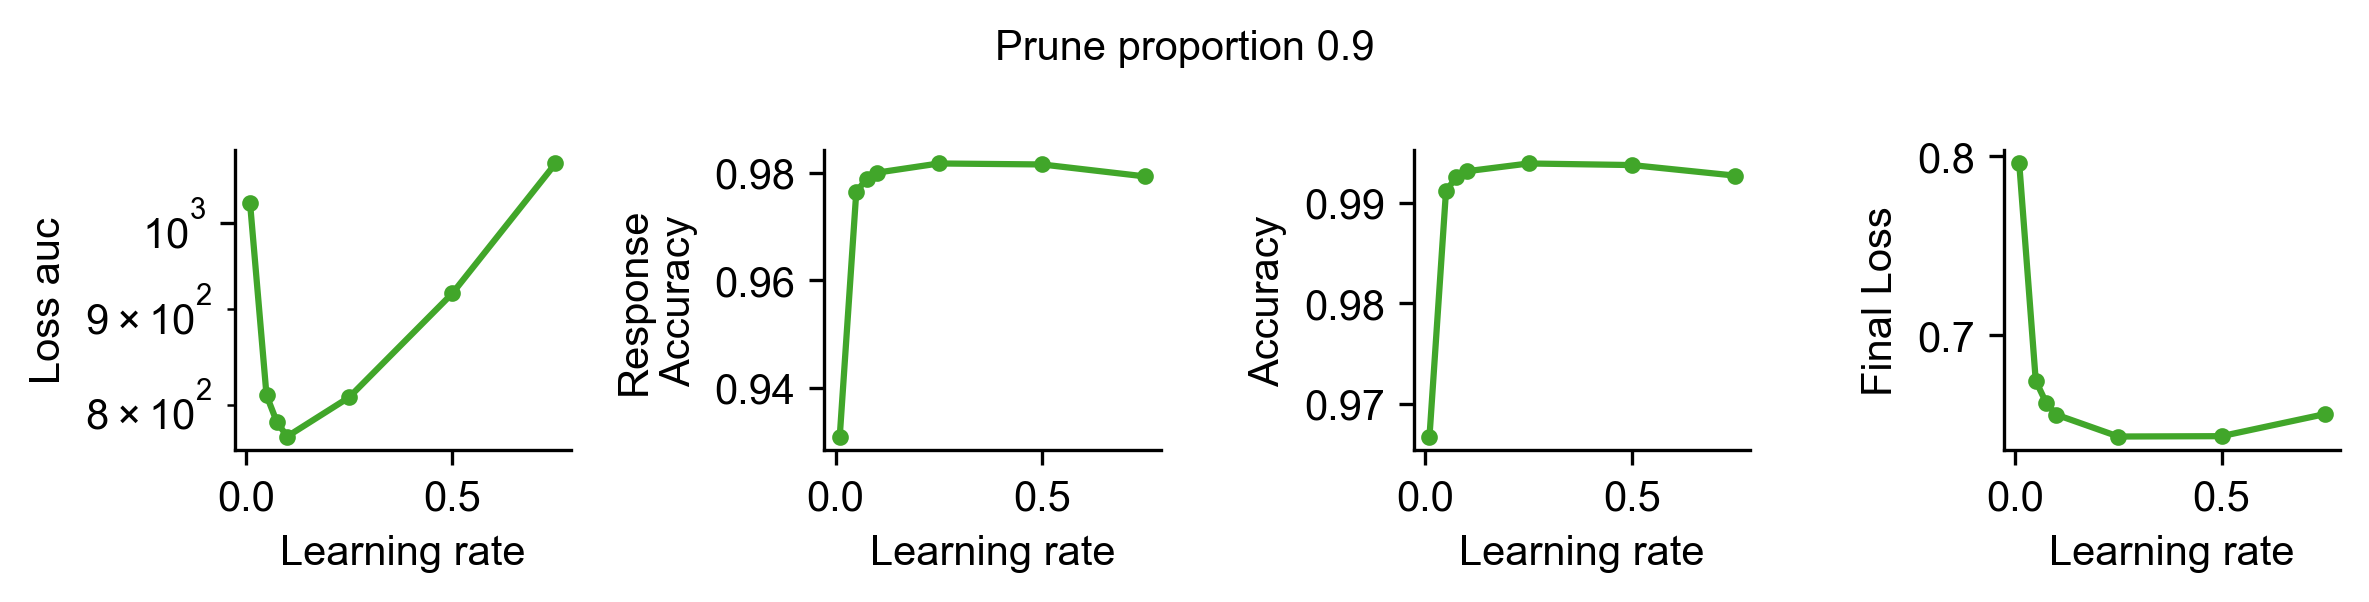

In [22]:
pp = '0.9'
fig = plot_sweep_summary(sweep_summary[pp], "cgd")
fig.suptitle(f"Prune proportion {pp}")

SweepResults(key='gd_lr0.1_m0.925', perf_metric=np.float64(784.9596699953079), test_dec_acc=np.float64(0.9793070874214171), test_acc=np.float64(0.9927104009389878), test_Loss=np.float64(0.6564018005132676))
['m0.925']
[np.float64(0.9190157395601272), np.float64(0.9735874561071396), np.float64(0.9776036362648011), np.float64(0.9793070874214171), np.float64(0.9817110277414323), np.float64(0.9816602878570556)]
[np.float64(1108.8153309464456), np.float64(842.443965613842), np.float64(803.7399345874786), np.float64(784.9596699953079), np.float64(799.4735233068466), np.float64(902.999037528038)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5]
(4,)


/tmp/ipykernel_2829383/3594726298.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_2829383/3594726298.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.9')

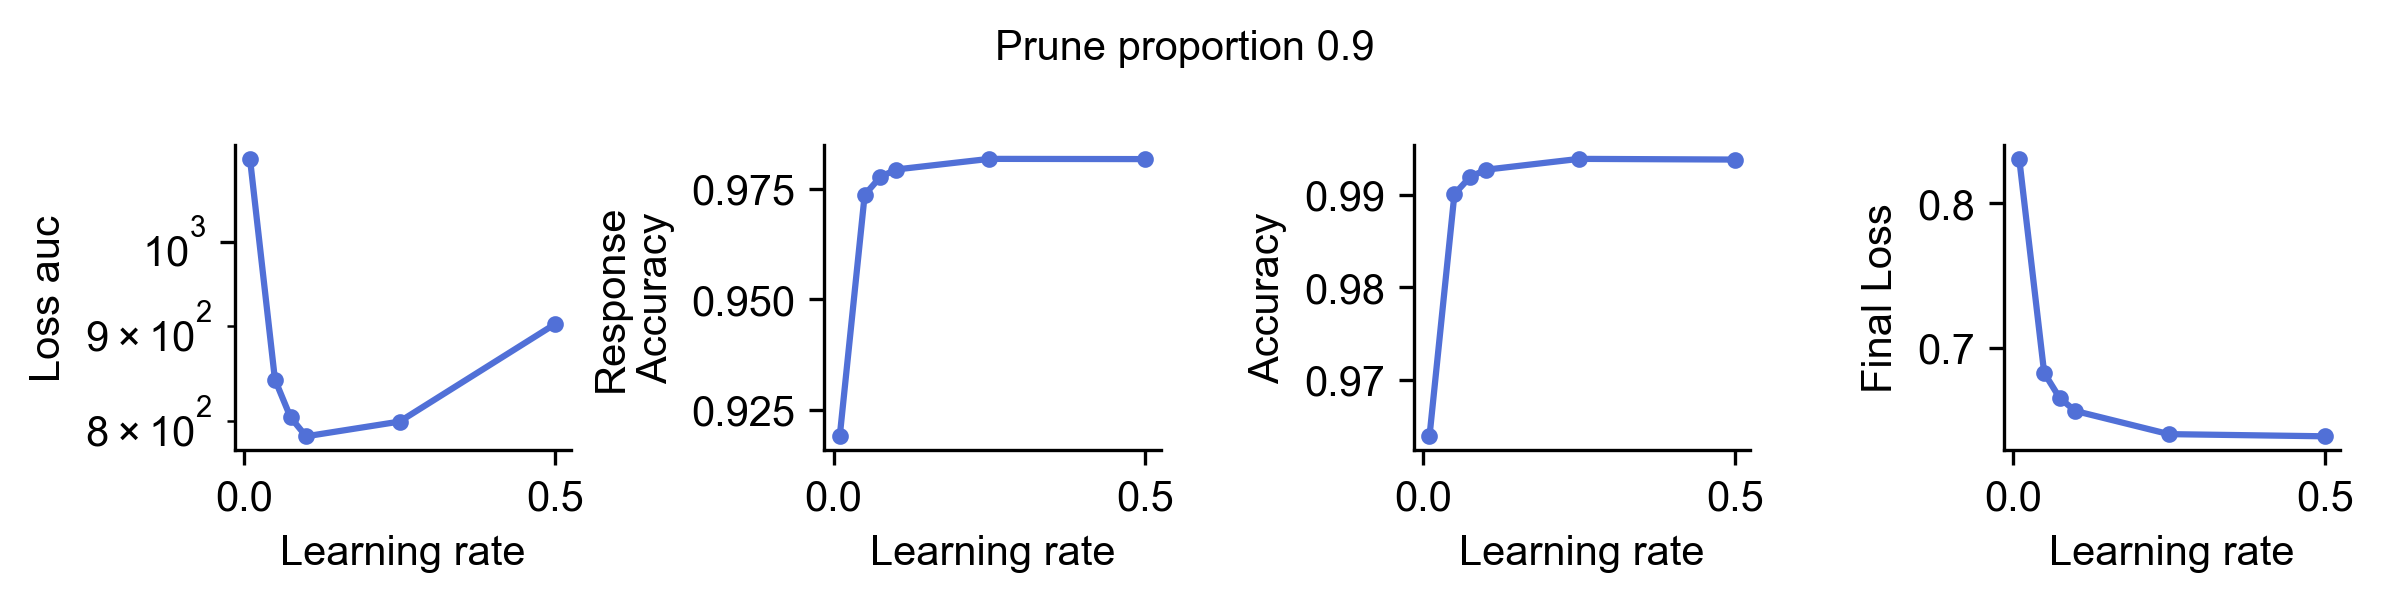

In [23]:
pp = '0.9'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

SweepResults(key='eg_lr2.0_m0.925', perf_metric=np.float64(681.4093374371529), test_dec_acc=np.float64(0.9826193169355392), test_acc=np.float64(0.9942127242088319), test_Loss=np.float64(0.6223822110891343))
['m0.925']
[np.float64(0.9745222702026366), np.float64(0.9810785213708877), np.float64(0.9817268534898759), np.float64(0.9820718106031417), np.float64(0.9823067250251769), np.float64(0.9824288531541823), np.float64(0.9826193169355392), np.float64(0.9827204085588456)]
[np.float64(819.0752954244614), np.float64(709.277362382412), np.float64(696.6232577204704), np.float64(689.5478130340576), np.float64(685.4312984228134), np.float64(682.7465432167053), np.float64(681.4093374371529), np.float64(682.4206635355949)]
[0.1, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5]
(4,)


/tmp/ipykernel_2829383/3594726298.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_2829383/3594726298.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

Text(0.5, 0.98, 'Prune proportion 0.9')

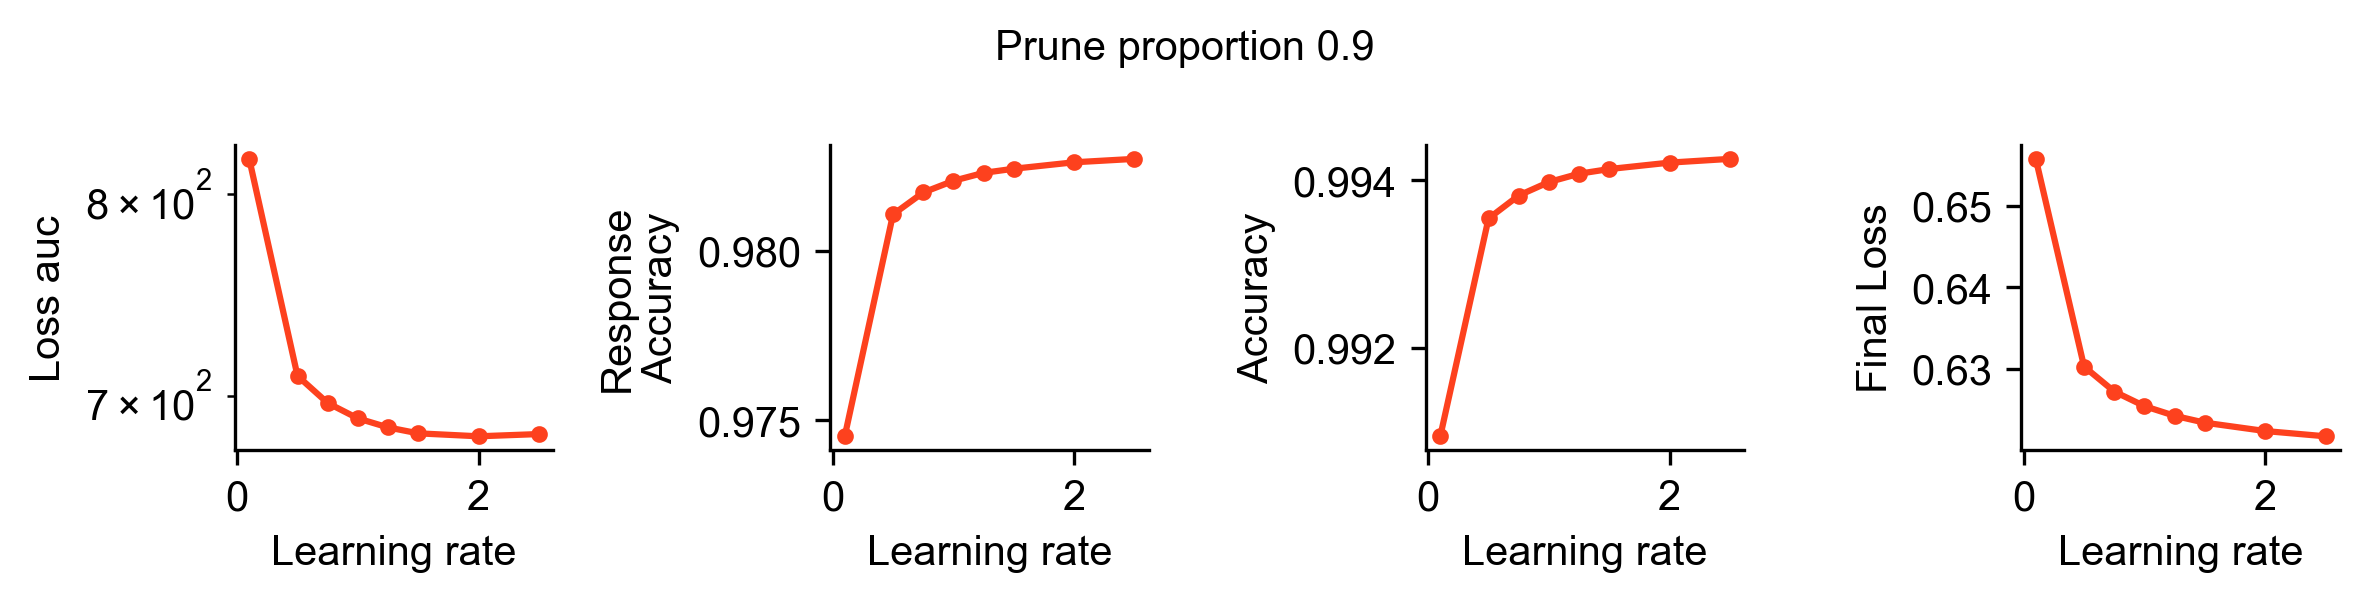

In [24]:
pp = '0.9'
fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1.5_m0.925 0.9701033949851989
gd_lr0.25_m0.925 0.9678131699562073
cgd_lr0.25_m0.925 0.9682175517082214
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1.5_m0.925 0.9817898197174072
gd_lr0.25_m0.925 0.980120357990265
cgd_lr0.25_m0.925 0.9803190282583236


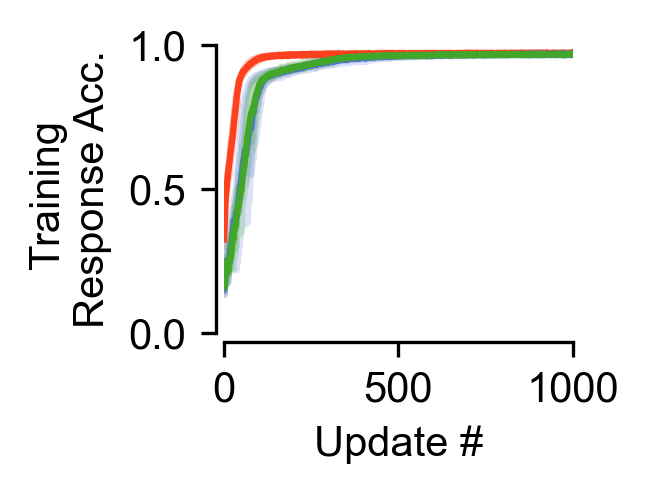

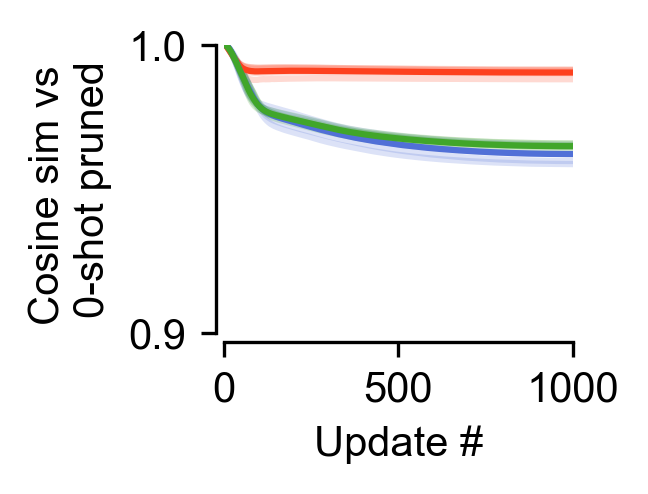

In [25]:
pp = "0.925"
fig1, fig2 = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], best_settings[pp].cgd[0], results_dict[pp], pp=pp)
# fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300,transparent=True)
# fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.25_m0.925', perf_metric=np.float64(844.7261702537537), test_dec_acc=np.float64(0.980120357990265), test_acc=np.float64(0.9932204364538194), test_Loss=np.float64(0.6510167988538742))
['m0.925']
[np.float64(0.8679547770023344), np.float64(0.9476784889698029), np.float64(0.9653043923377991), np.float64(0.9731578885316848), np.float64(0.980120357990265), np.float64(0.9807234896421433), np.float64(0.9778866944313048)]
[np.float64(1438.0577757000924), np.float64(977.8703836321831), np.float64(913.7436240196228), np.float64(878.3365096092224), np.float64(844.7261702537537), np.float64(927.4647597789765), np.float64(13180271850.005833)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=np.float64(710.0907239437104), test_dec_acc=np.float64(0.9817898197174072), test_acc=np.float64(0.9938681906461715), test_Loss=np.float64(0.626950756907463))
['m0.925']
[np.float64(0.9561582707166671), np.float64(0.9795297895669938), np.float6

/tmp/ipykernel_2829383/3594726298.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_2829383/3594726298.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

SweepResults(key='cgd_lr0.25_m0.925', perf_metric=np.float64(842.1258703231812), test_dec_acc=np.float64(0.9803190282583236), test_acc=np.float64(0.9932598890066145), test_Loss=np.float64(0.6529766087532043))
['m0.925']
[np.float64(0.8848052874803543), np.float64(0.9535027190446852), np.float64(0.9698124455213547), np.float64(0.9754120860099793), np.float64(0.9803190282583236), np.float64(0.9794180519580842), np.float64(0.9737019413709641)]
[np.float64(1315.2362193346023), np.float64(940.7804708361625), np.float64(885.075045979023), np.float64(854.3629404902458), np.float64(842.1258703231812), np.float64(1002.7705571055412), np.float64(1083.173172688484)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)


Text(0.5, 0.98, 'Prune proportion 0.925')

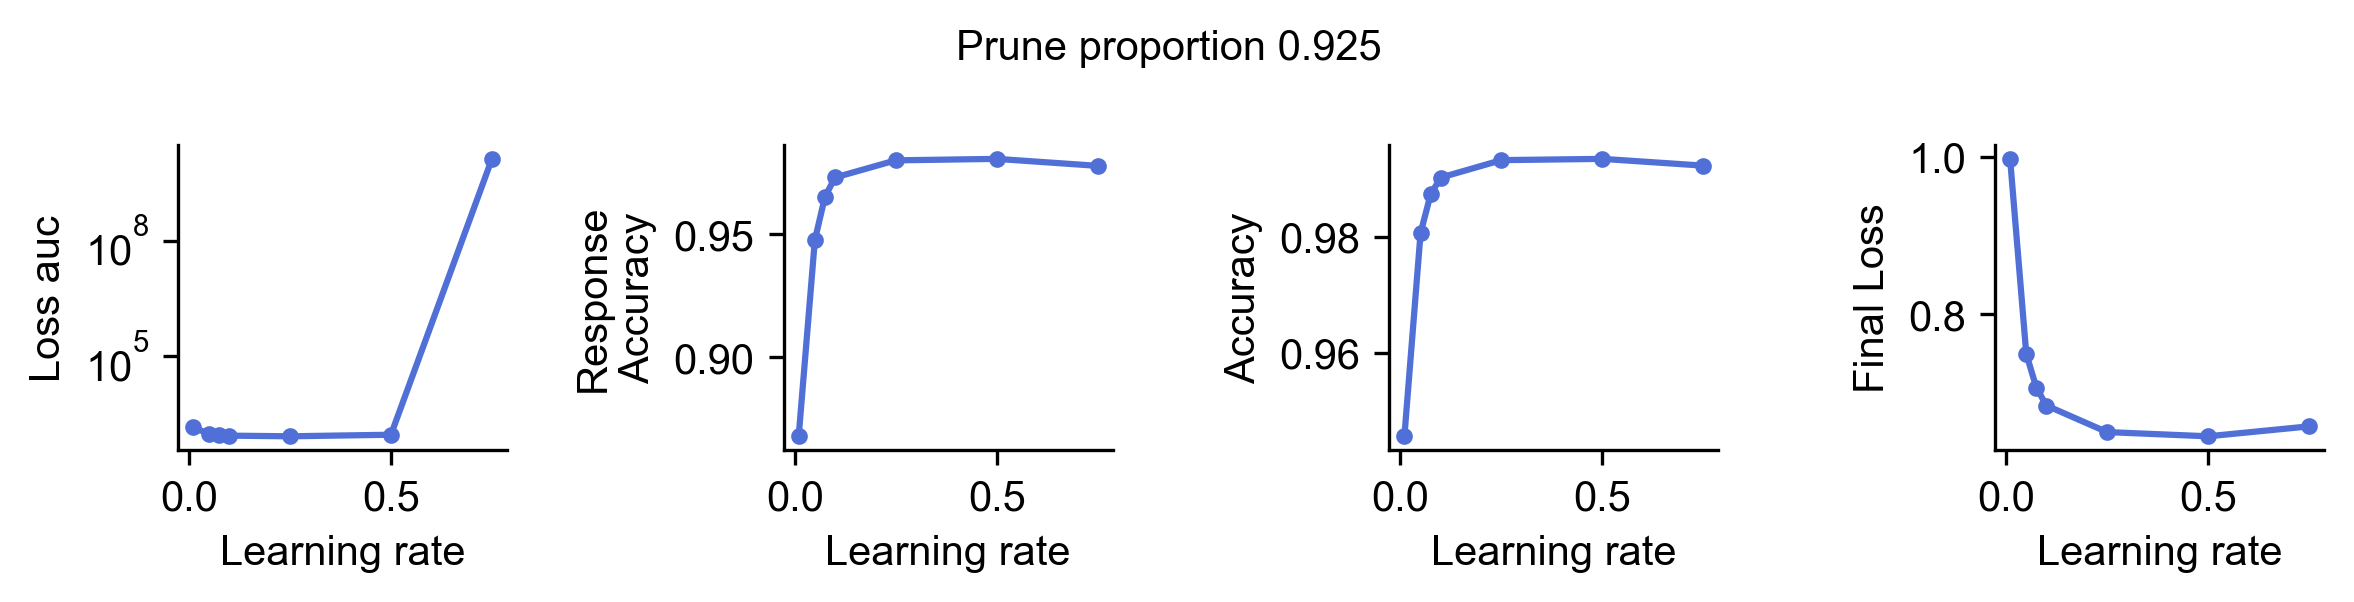

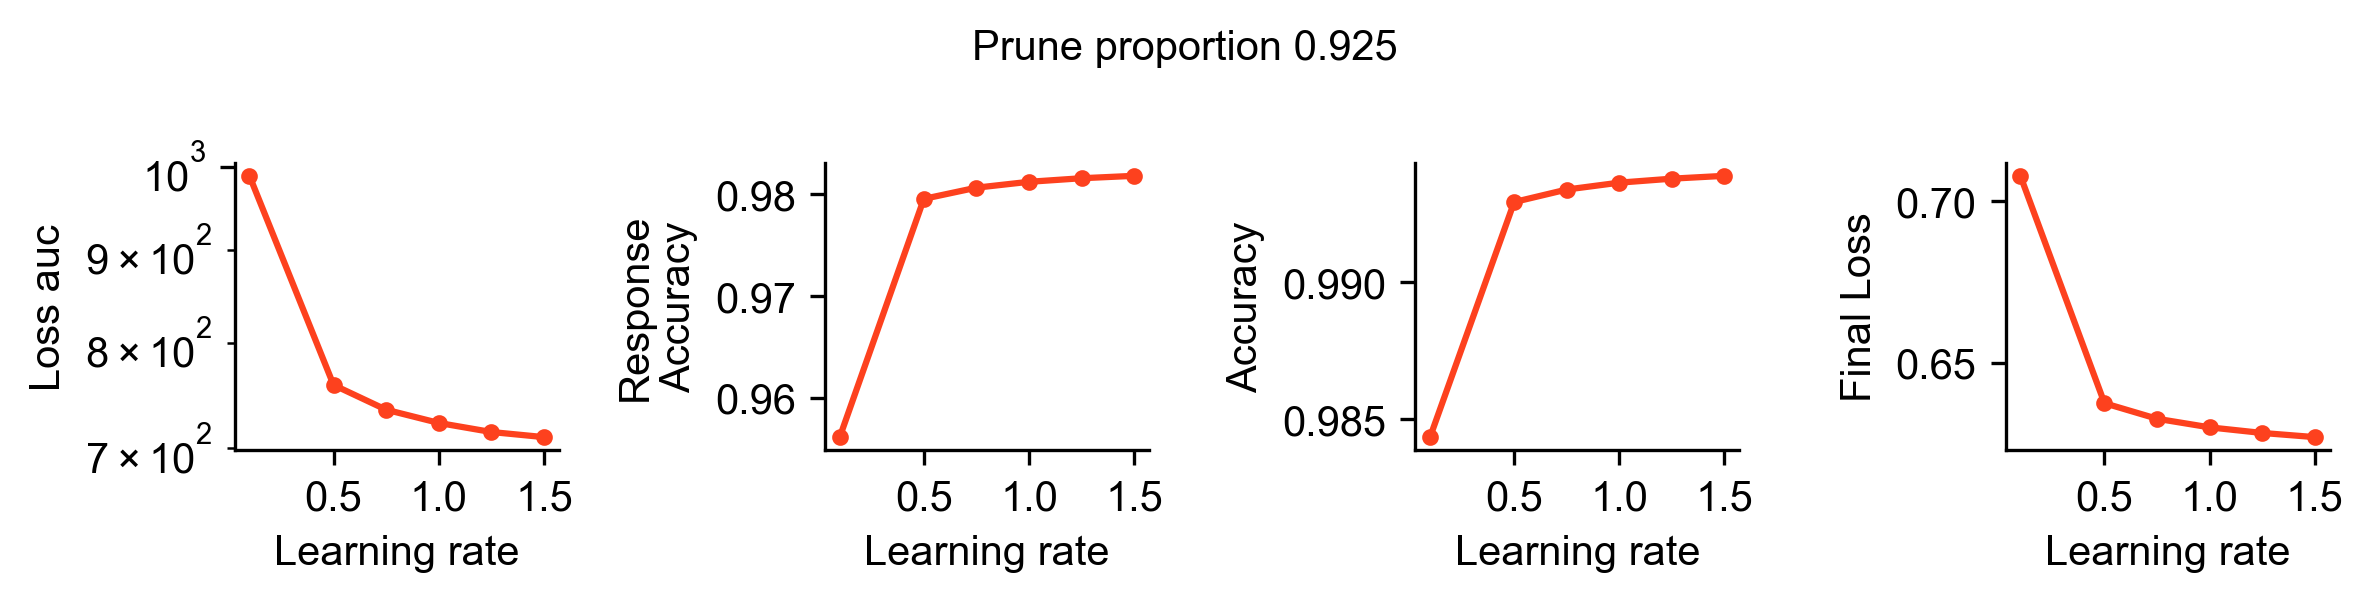

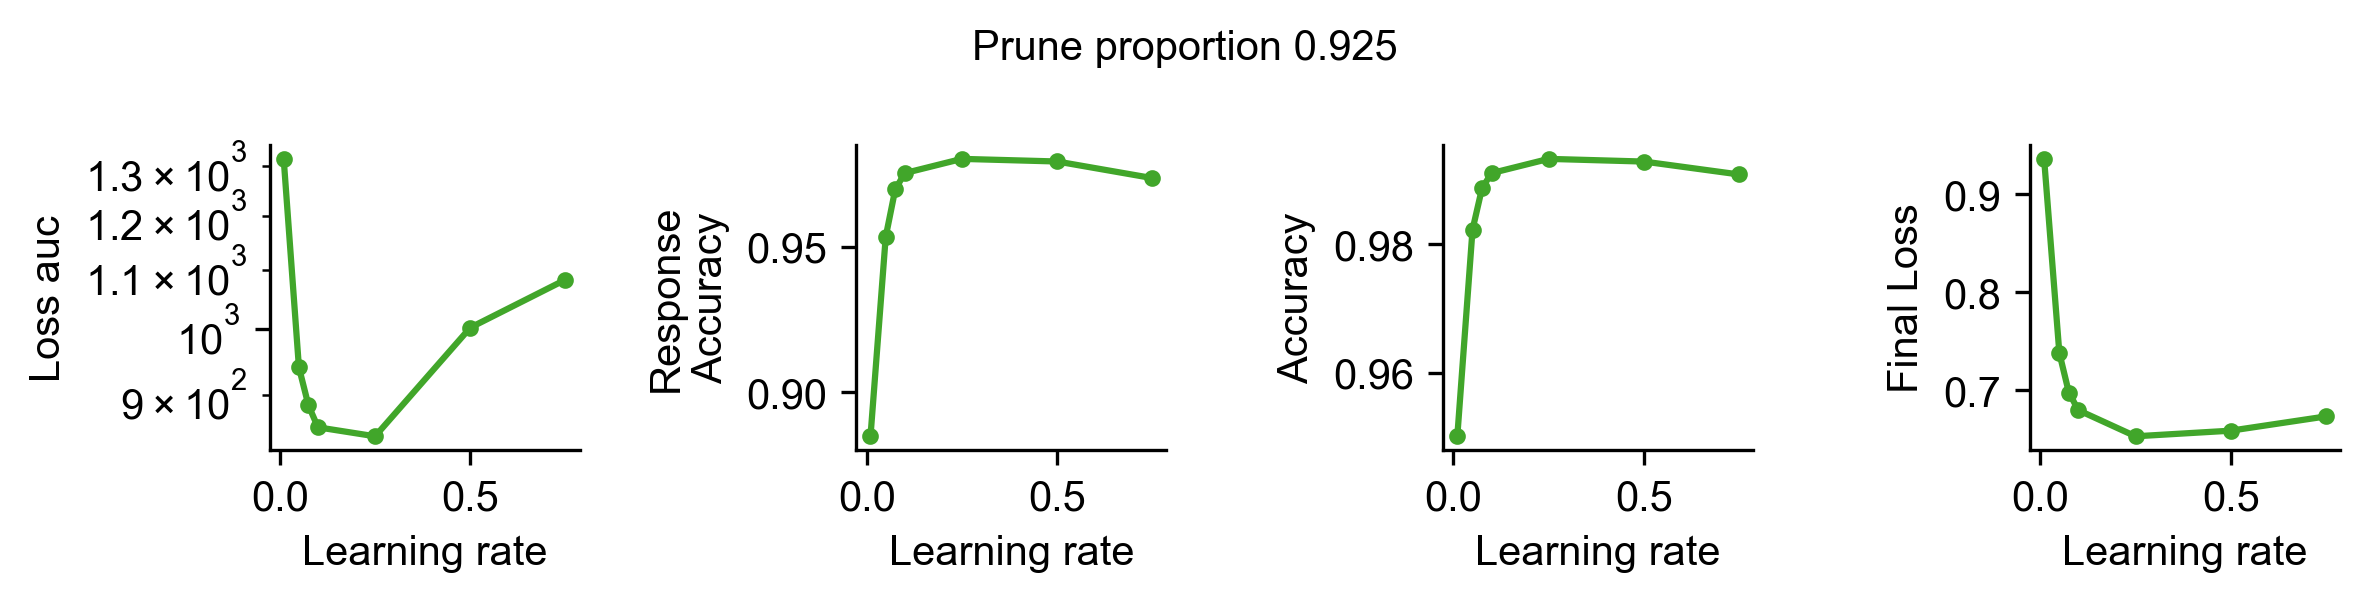

In [26]:
# we don't have the higher lrs due to nans

pp = '0.925'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "cgd")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1_m0.925 0.9655419707298278
gd_lr0.1_m0.925 0.9154142022132874
cgd_lr0.25_m0.925 0.9382995724678039
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1_m0.925 0.9786926603317262
gd_lr0.1_m0.925 0.9344824334383011
cgd_lr0.25_m0.925 0.9583437741994858


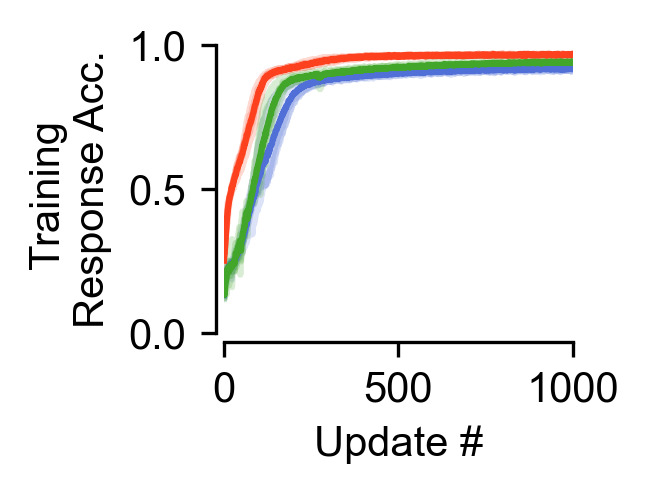

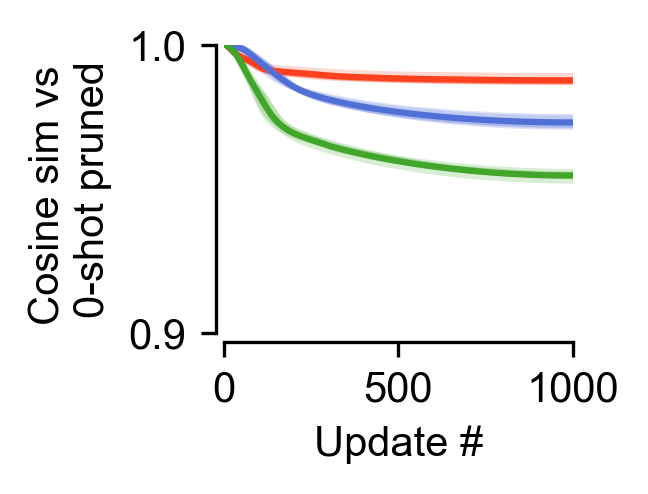

In [27]:
pp = "0.95"
fig1, fig2 = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], best_settings[pp].cgd[0], results_dict[pp], pp=pp)

# fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300,transparent=True)
# fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.1_m0.925', perf_metric=np.float64(1075.0028334498406), test_dec_acc=np.float64(0.9344824334383011), test_acc=np.float64(0.9769016183614732), test_Loss=np.float64(0.7806765410900115))
['m0.925']
[np.float64(0.5522076559662819), np.float64(0.9066900764703749), np.float64(0.9228014057874679), np.float64(0.9344824334383011), np.float64(0.9578502085208893), np.float64(0.9589491746425628), np.float64(0.9426329348087311)]
[np.float64(2170.89141626358), np.float64(1256.0020872116088), np.float64(1138.660954761505), np.float64(1075.0028334498406), np.float64(5956466.16473552), np.float64(6037788478.046559), np.float64(1361769829655272.2)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)
SweepResults(key='eg_lr1_m0.925', perf_metric=np.float64(804.7632028579712), test_dec_acc=np.float64(0.9786926603317262), test_acc=np.float64(0.9925171216726303), test_Loss=np.float64(0.6410590252876281))
['m0.925']
[np.float64(0.8358781843185424), np.float64(0.9720900385379793), np.float6

/tmp/ipykernel_2829383/3594726298.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_2829383/3594726298.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

[np.float64(0.62133901822567), np.float64(0.9081375311613084), np.float64(0.9236361941099167), np.float64(0.9348431787490845), np.float64(0.9583437741994858), np.float64(0.9605368642807006), np.float64(0.9438770623207093)]
[np.float64(2011.3498311042786), np.float64(1198.8792245030404), np.float64(1098.90282651186), np.float64(1049.425713980198), np.float64(992.0463211655617), np.float64(1075.884935617447), np.float64(1207.2412068605422)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)


Text(0.5, 0.98, 'Prune proportion 0.95')

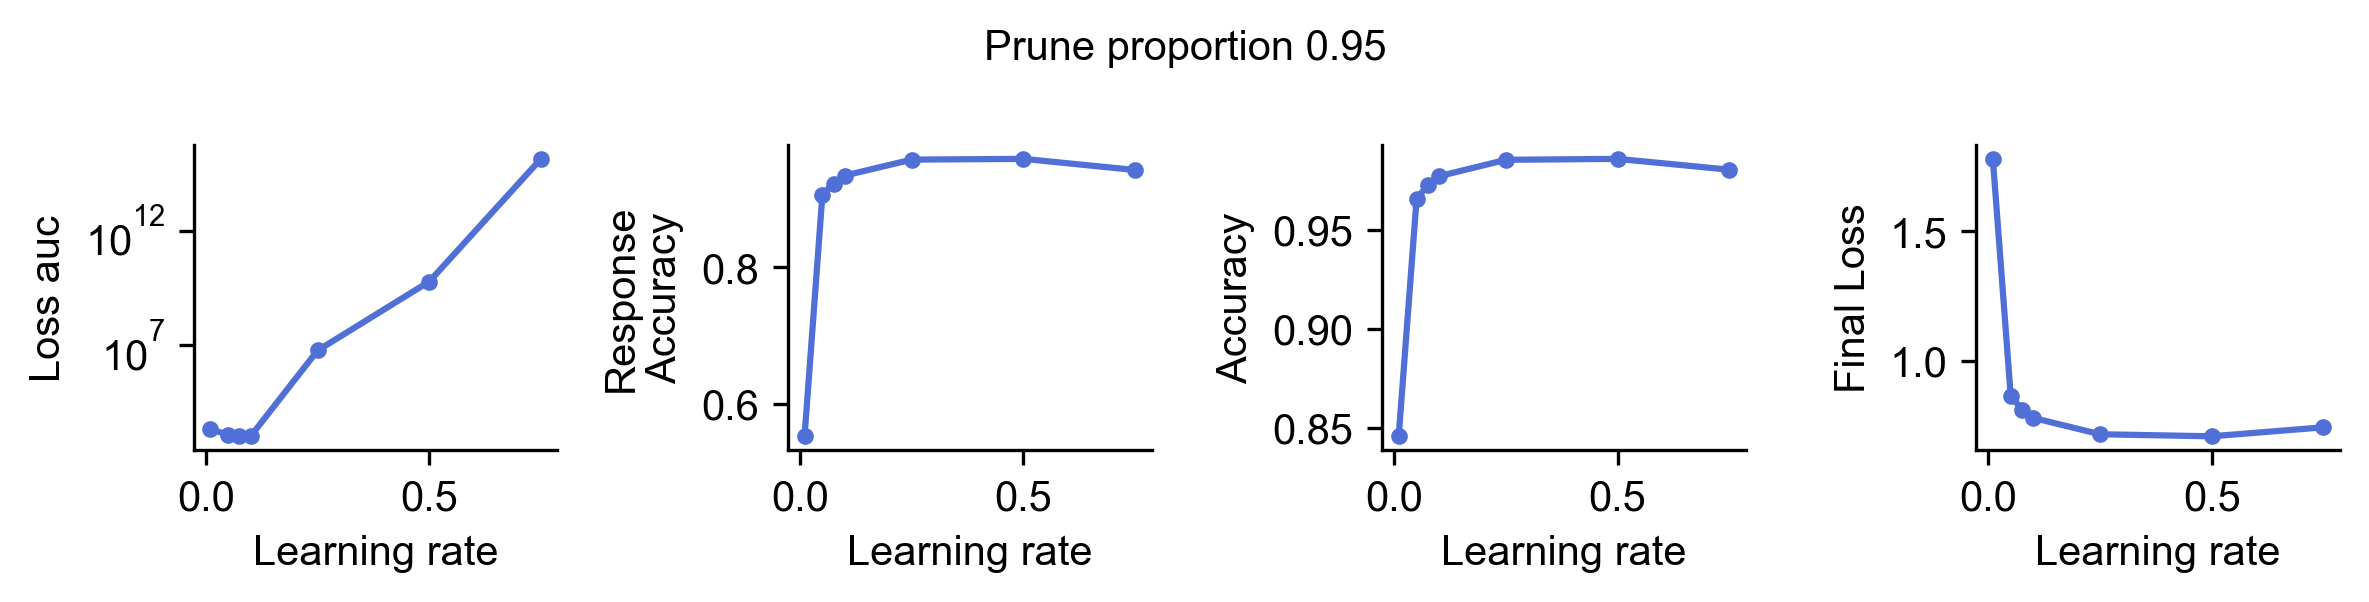

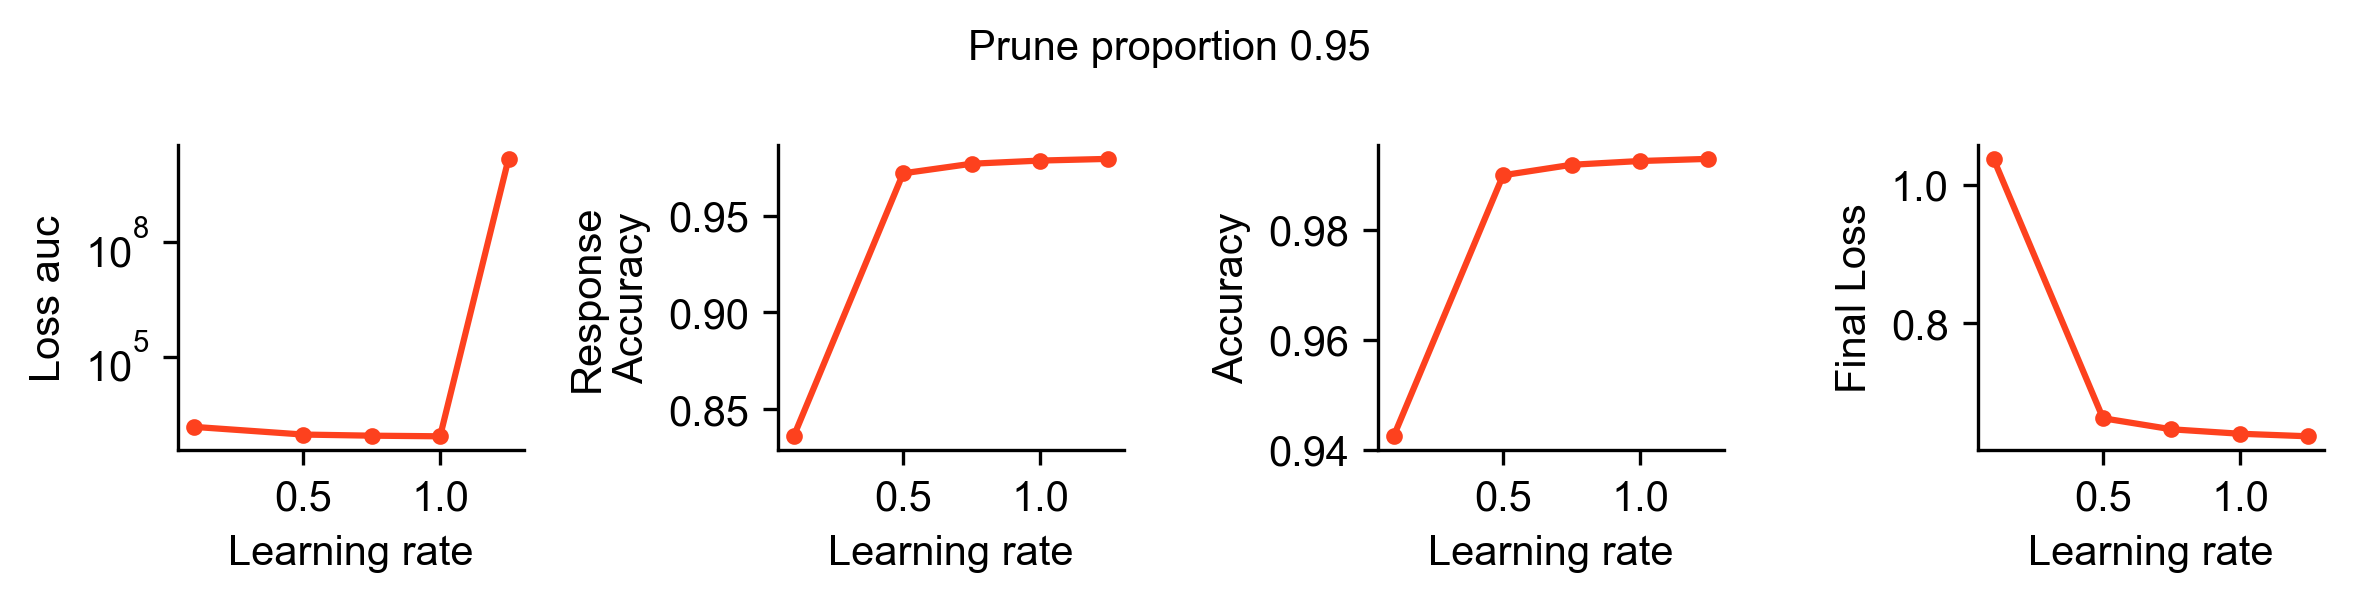

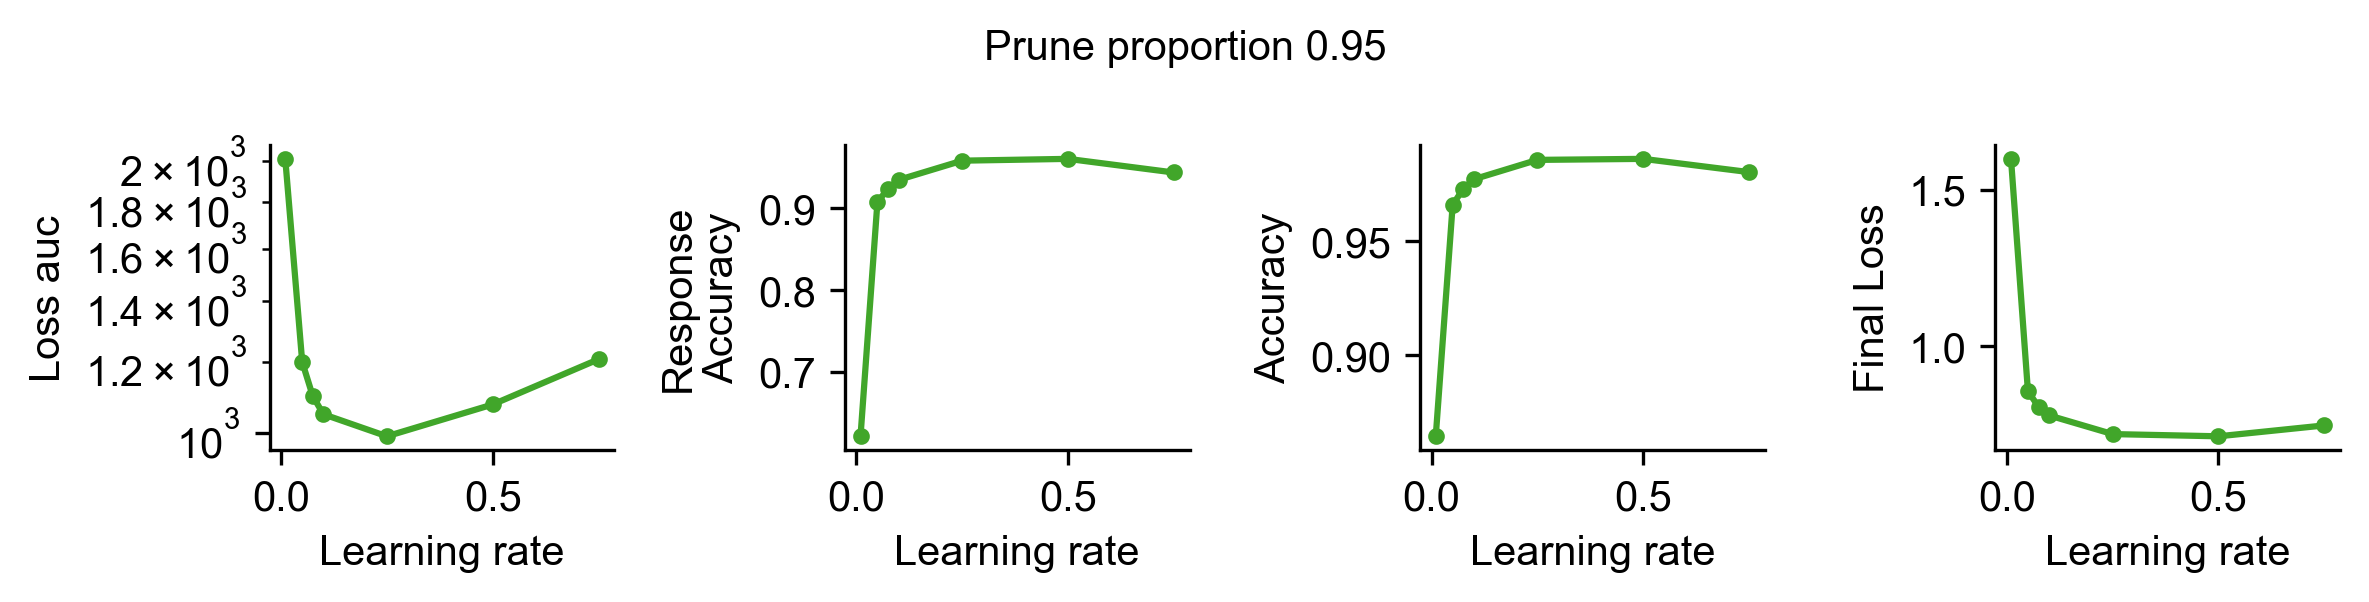

In [28]:
# we don't have the higher lrs due to nans
pp = '0.95'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "cgd")
fig.suptitle(f"Prune proportion {pp}")

eg_lr1.5_m0.925 0.9125974774360657
gd_lr0.25_m0.925 0.8891444444656372
cgd_lr0.25_m0.925 0.8871896743774415
dict_keys(['val_Acc', 'val_Dec_Acc', 'val_Loss', 'test_Acc', 'test_Dec_Acc', 'test_Loss'])
eg_lr1.5_m0.925 0.9293568518161773
gd_lr0.25_m0.925 0.9066642404794694
cgd_lr0.25_m0.925 0.9068915792703628


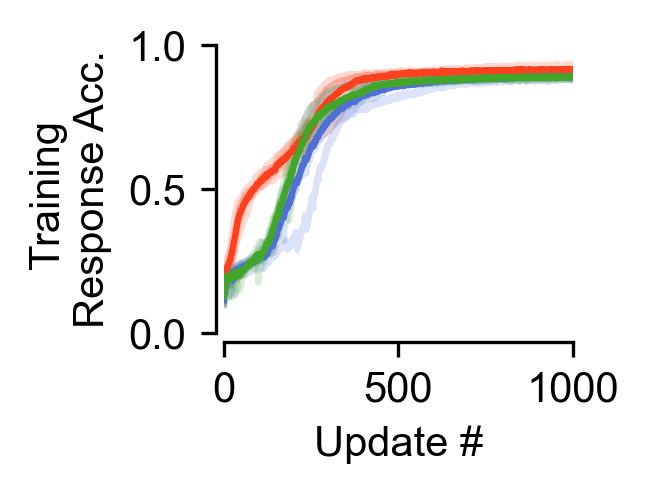

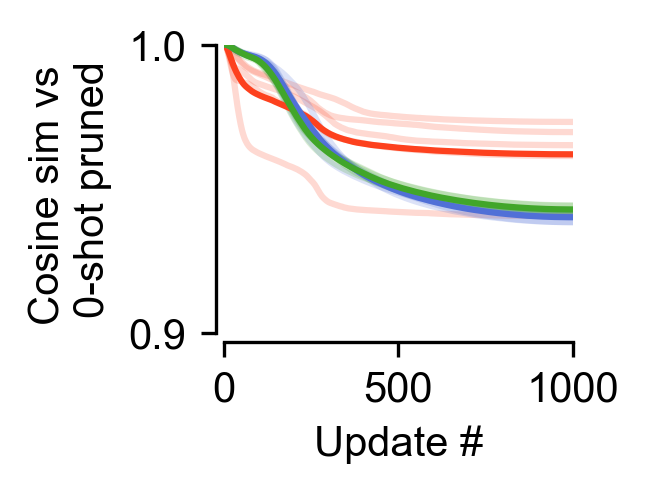

In [29]:
pp = "0.975"
fig1, fig2 = plot_best_results(best_settings[pp].eg[0], best_settings[pp].gd[0], best_settings[pp].cgd[0], results_dict[pp], pp=pp)
# fig1.savefig(f'figs/fig2/{pp}_acc.pdf', dpi=300,transparent=True)
# fig2.savefig(f'figs/fig2/{pp}_cos_sim.pdf', dpi=300,transparent=True)

SweepResults(key='gd_lr0.25_m0.925', perf_metric=np.float64(1328.3344507932663), test_dec_acc=np.float64(0.9066642404794694), test_acc=np.float64(0.9676907937526703), test_Loss=np.float64(0.85468858730793))
['m0.925']
[np.float64(0.24596513971686362), np.float64(0.5289636499881745), np.float64(0.7631306602954864), np.float64(0.8469992361068727), np.float64(0.9066642404794694), np.float64(0.9151857159137726), np.float64(0.912573788046837)]
[np.float64(2583.3737946987153), np.float64(2259.9801535129545), np.float64(1914.0425350904466), np.float64(1696.623775792122), np.float64(1328.3344507932663), np.float64(1331.330009841919), np.float64(19872.527981388568)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)
SweepResults(key='eg_lr1.5_m0.925', perf_metric=np.float64(1108.333184850216), test_dec_acc=np.float64(0.9293568518161773), test_acc=np.float64(0.9756163843870164), test_Loss=np.float64(0.7670705729722977))
['m0.925']
[np.float64(0.5575385763645173), np.float64(0.8611783322095871), np.f

/tmp/ipykernel_2829383/3594726298.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0].plot(lrs, perf_metrics, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[1].plot(lrs, test_dec_accs, "o-", markersize=ms, c=c, linestyle=linestyles[i])
/tmp/ipykernel_2829383/3594726298.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[2].plot(lrs, test_accs, "o-", markersize=ms, c=c,linestyle=linestyles[i] )
/tmp/ipykernel_2829383/3594726298.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argume

SweepResults(key='cgd_lr0.25_m0.925', perf_metric=np.float64(1282.452913570404), test_dec_acc=np.float64(0.9068915792703628), test_acc=np.float64(0.9680289962291717), test_Loss=np.float64(0.8491962407827378))
['m0.925']
[np.float64(0.25143902844190597), np.float64(0.629002514719963), np.float64(0.7918228535652161), np.float64(0.8503522679805755), np.float64(0.9068915792703628), np.float64(0.9128873587846755), np.float64(0.902113020658493)]
[np.float64(2574.8192306995393), np.float64(2097.4022577524183), np.float64(1785.8461940288544), np.float64(1606.2822702884673), np.float64(1282.452913570404), np.float64(1913679.518367064), np.float64(392192939.99662876)]
[0.01, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75]
(4,)


Text(0.5, 0.98, 'Prune proportion 0.975')

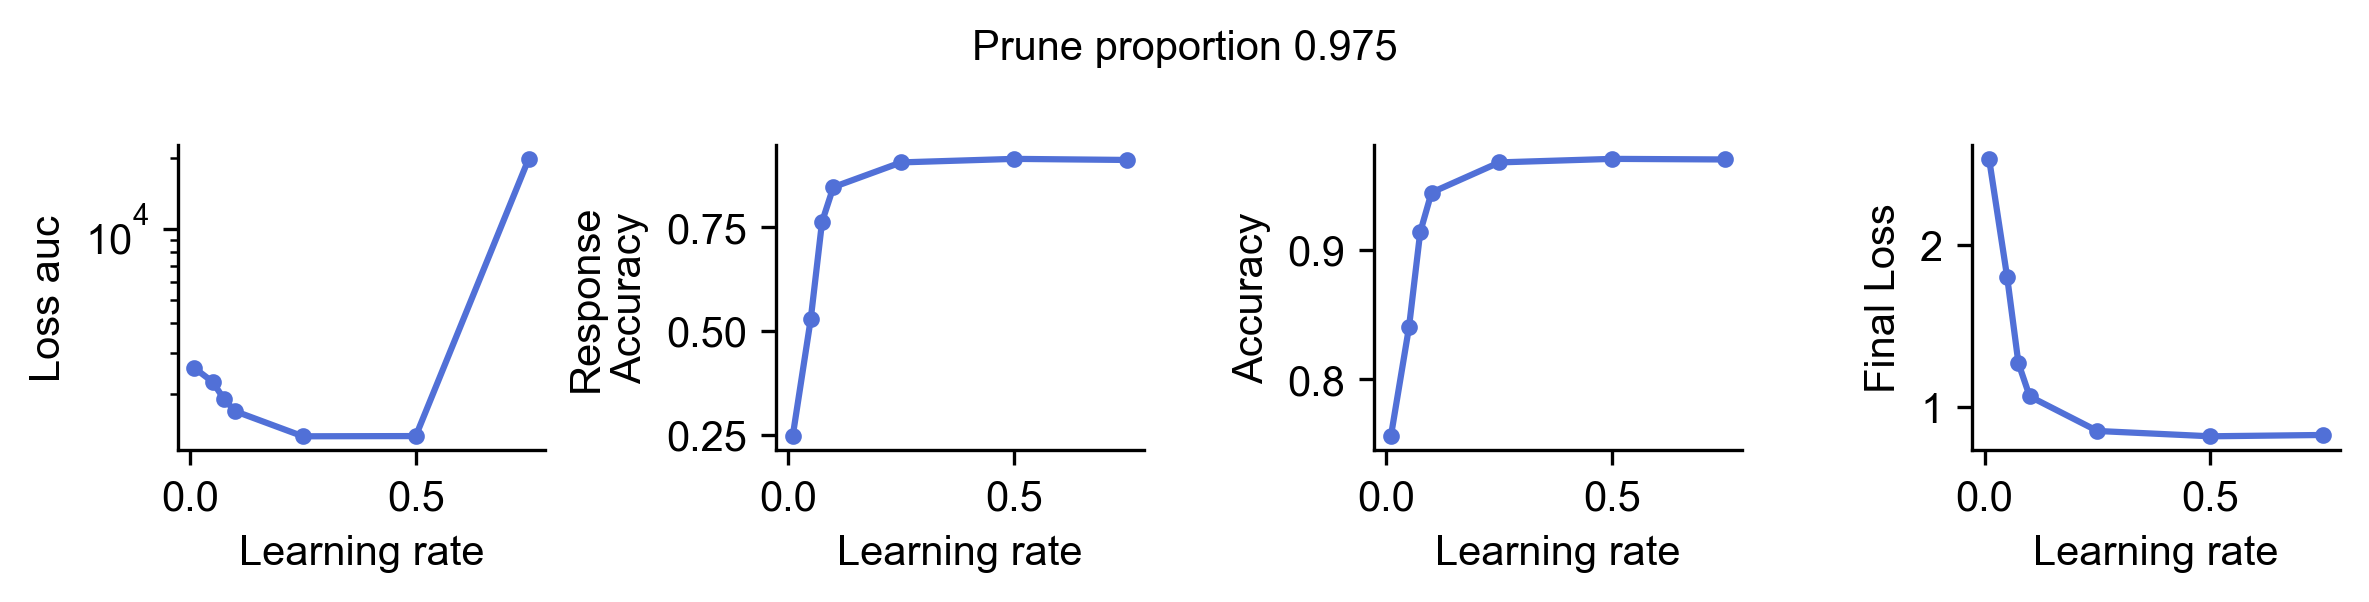

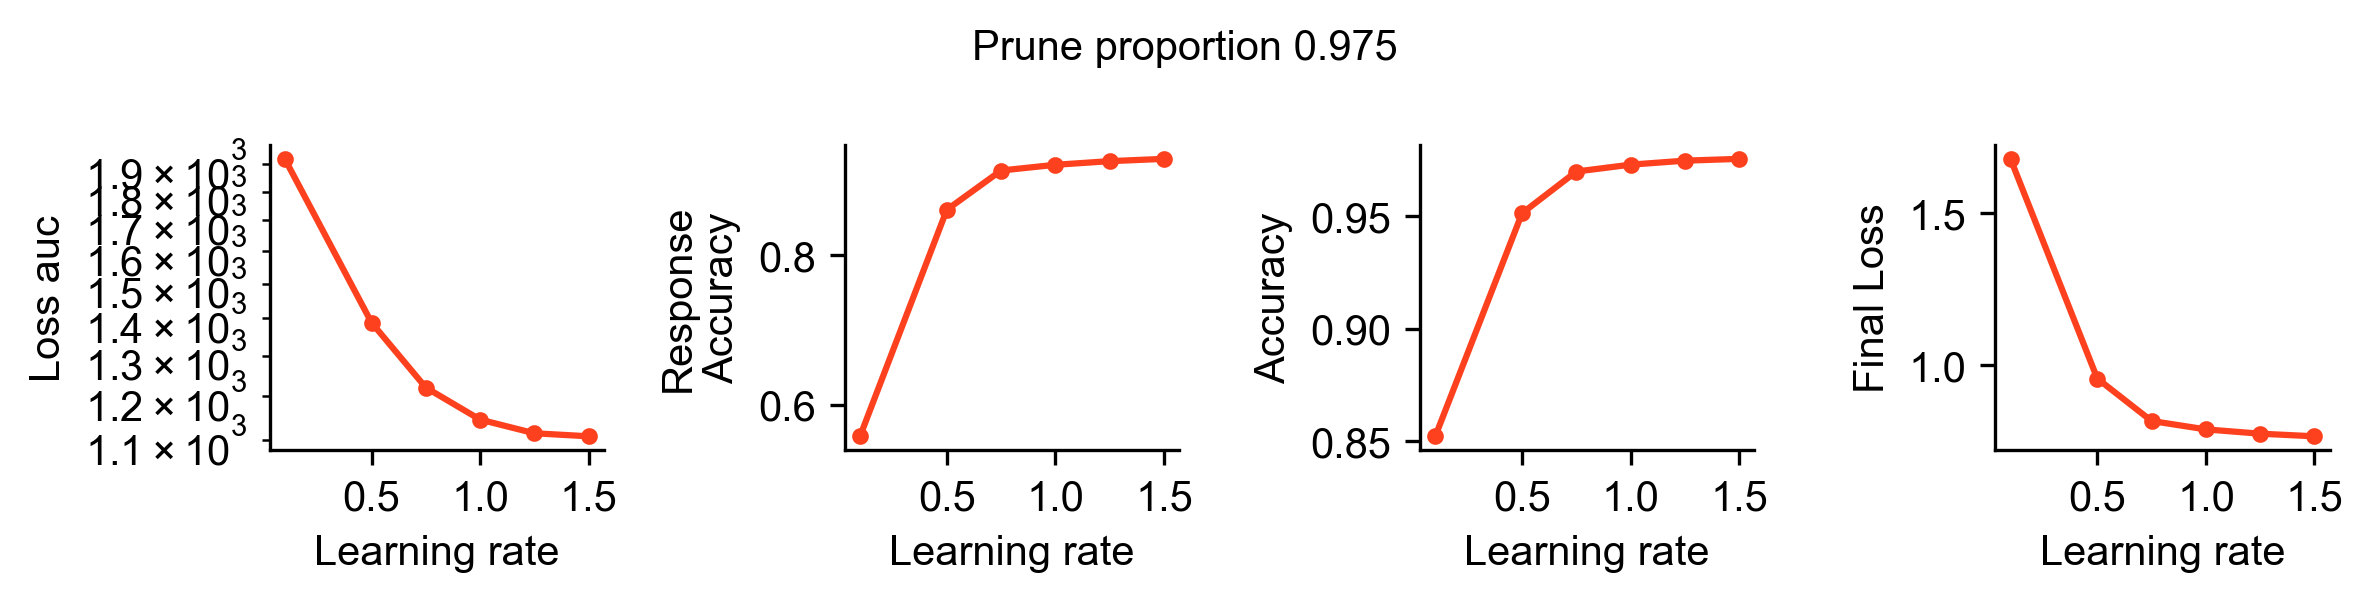

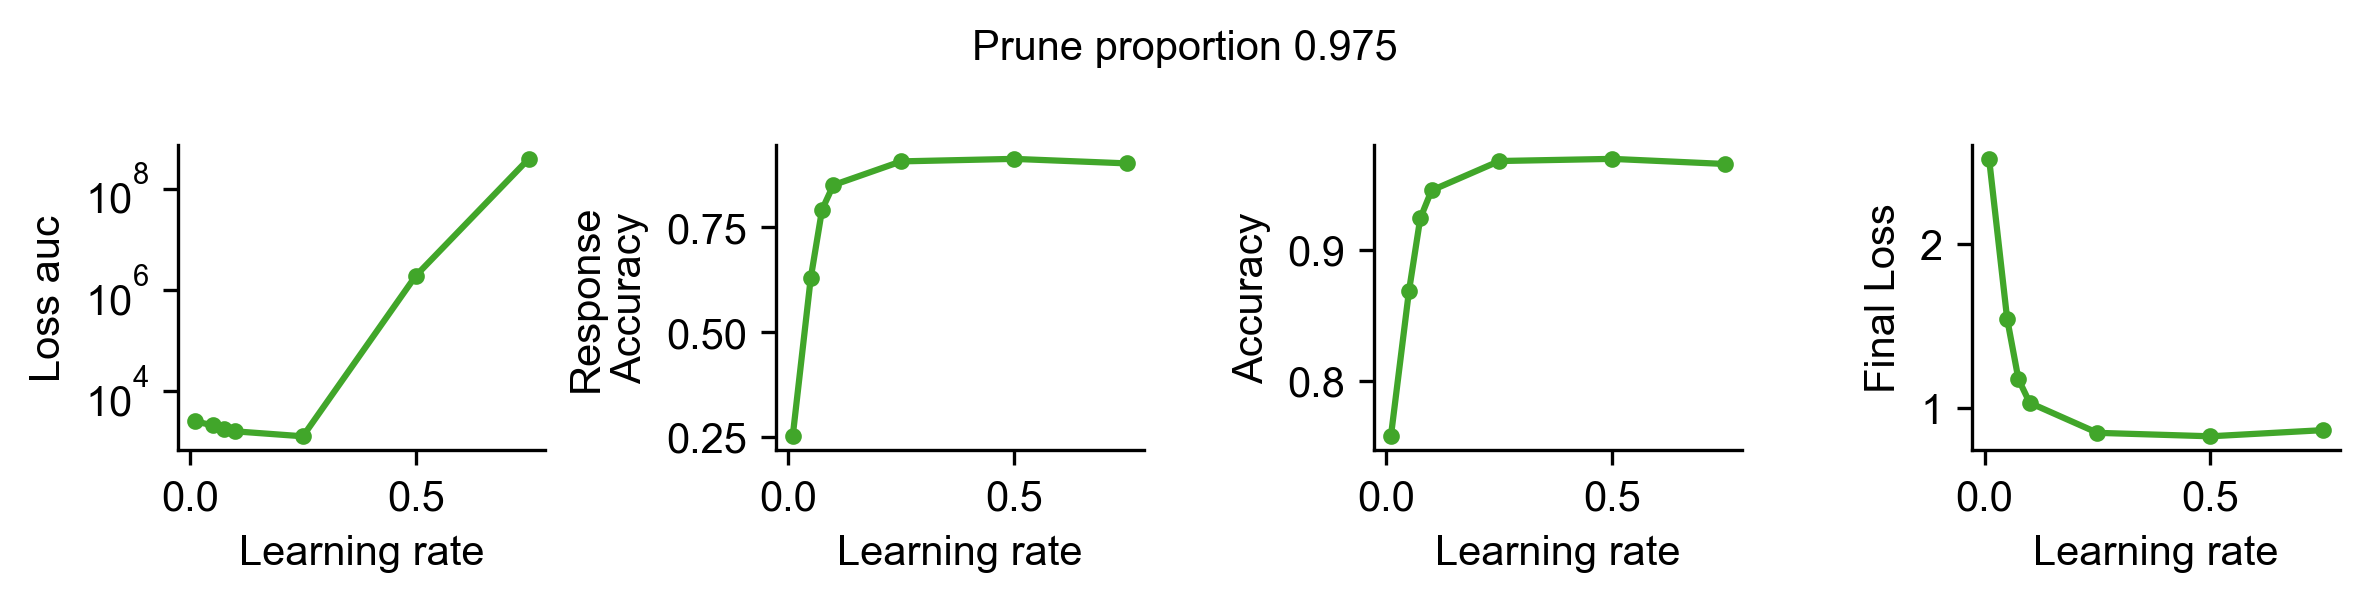

In [30]:
# we don't have the higher lrs due to nans
pp = '0.975'
fig = plot_sweep_summary(sweep_summary[pp], "gd")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "eg")
fig.suptitle(f"Prune proportion {pp}")

fig = plot_sweep_summary(sweep_summary[pp], "cgd")
fig.suptitle(f"Prune proportion {pp}")